# Module 3 — From Zero to Pro: Build Your Own Earth-Observation Database

**Earth-Observation Workshop · Mar Menor coastal lagoon (Murcia, Spain) · NYU PhD**
*Duration: ~90 min · the "do it yourself for your own project" module*

---

Modules 1 and 2 handed you ready-made data. **This module teaches you to get the
data yourself** — live, from real public servers — and turn it into a database
you can query for your own study. Everything here **runs in class with no
account and no API key**: you will press *Shift+Enter* and watch real satellite
and environmental data arrive on your screen.

> 🟢 **Cells marked "LIVE" make a real network request** when you run them. If you
> are offline they print a short notice and the notebook keeps working from the
> cached files — nothing breaks.

## What you will do, in plain terms

| Part | In one sentence | You end up with |
|------|-----------------|-----------------|
| **1. Discover & download** | "Where is the free data and how do I pull it *right now*?" | Real images + time series on screen |
| **2. Clean & QA** | "Which pixels can I trust?" | Only good observations |
| **3. Extract** | "Turn pixels into tidy numbers." | A long-format table |
| **4. Store** | "Put it in a database the right way." | `marmenor.db` + Parquet |
| **5. Analyse** | "Ask pollution questions in SQL." | Trends, exceedances, a study |
| **6. Scale** | "Make it grow on its own." | A repeatable pipeline |

## The mental model (read this once)

Think of an Earth-observation project as a **kitchen**:

- **Part 1 is the grocery run** — you fetch raw ingredients (pixels, sensor
  readings) from different shops (satellite archives, ocean models, air-quality
  APIs). Some shops are open to everyone (no login); a few are members-only.
- **Part 2 is washing the vegetables** — throw away the rotten bits (clouds, land
  pixels, sensor gaps).
- **Part 3 is chopping** — cut everything into the same tidy shape.
- **Part 4 is the fridge** — store it so you can find it again (the database).
- **Part 5 is cooking** — combine ingredients into a dish (the pollution study).
- **Part 6 is running a restaurant** — do it every day without re-inventing it.

Keep that picture in mind; every section maps to one step.

## Environment

```bash
pip install -r requirements.txt
```

`sqlite3` ships with Python. The live cells only need `requests` + `rasterio`,
already in `requirements.txt`.


---
## ▶️ How to run this notebook

Open the **Table of contents** (☰, top-left) to jump between the six parts.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RicardoTeruelGutierrez/marmenor-eo-workshop/blob/main/notebooks/03_build_database.ipynb)

1. **In Colab:** click the badge, then **Runtime → Run all**. First cell installs everything (~30 s).
2. **On your laptop:** `pip install -r requirements.txt`, then run top to bottom.
3. **Run cells in order** — each builds on the previous.
4. **What you need:** most cells need no account. Part 1.5 (Copernicus) is where you register and paste your own API key, live.

**Cell labels you'll see:**

| Label | Meaning |
|-------|---------|
| 🟢 **RUN** | Just run it — fetches real data or builds a result. |
| ✏️ **EDIT** | Change a value (a date, your credentials) before running. |
| ⏭️ **OPTIONAL** | Pattern/reference — safe to skip; won't break later cells. |

*Run the bootstrap cell below first (it does nothing on a local install).*


In [1]:
# Colab bootstrap (no-op on a local install)
import sys, os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not os.path.exists("/content/workshop"):
    print("Running in Colab - bootstrapping (~30s)...")
    !git clone -q https://github.com/RicardoTeruelGutierrez/marmenor-eo-workshop.git /content/workshop
    !pip install -q -r /content/workshop/requirements.txt
    !python /content/workshop/scripts/generate_datasets.py
if IN_COLAB:
    %cd /content/workshop/notebooks
    print("Ready - run the cells below.")


---
## Setup — run this first

This cell loads the libraries, points at the folders and defines our **study
area** (the Mar Menor bounding box). For *your* project you would change only
`AOI` and the lagoon outline — everything else stays the same.


In [2]:
# ── Dependency check ──────────────────────────────────────────────────────
import importlib.util
_required = ["numpy", "pandas", "pyarrow", "rasterio", "matplotlib", "scipy", "requests"]
_missing  = [p for p in _required if importlib.util.find_spec(p) is None]
if _missing:
    raise ImportError("Missing packages: " + ", ".join(_missing) +
                      "\nRun:  pip install -r requirements.txt")

import warnings, json, sqlite3, io, time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import rasterio
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.dates as mdates
from matplotlib.path import Path as MplPath

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

DATA   = Path("../data").resolve()
DB_DIR = Path("../database").resolve()      # everything we BUILD lands here
DB_DIR.mkdir(parents=True, exist_ok=True)
(DB_DIR / "rasters").mkdir(exist_ok=True)
DB_PATH = DB_DIR / "marmenor.db"

# Study area (WGS84). Change these four numbers to study anywhere on Earth.
AOI = dict(lon_min=-0.882, lon_max=-0.700, lat_min=37.598, lat_max=37.812)
BBOX = (AOI["lon_min"], AOI["lat_min"], AOI["lon_max"], AOI["lat_max"])
LAGOON_LON, LAGOON_LAT = -0.79, 37.70        # a point inside the lagoon

_contour = DATA / "lagoon_contour_wgs84.npy"
LAGOON_POLY = np.load(_contour) if _contour.exists() else None

def have_internet(url="https://earth-search.aws.element84.com", timeout=5):
    try:
        requests.head(url, timeout=timeout); return True
    except Exception:
        return False

ONLINE = have_internet()
print("Setup complete.")
print(f"  Study area (bbox) : {BBOX}")
print(f"  Database target   : {DB_PATH}")
print(f"  Internet          : {'yes - LIVE cells will fetch real data' if ONLINE else 'no - cells fall back to cache'}")
print(f"  Lagoon outline    : {'loaded' if LAGOON_POLY is not None else 'missing (optional)'}")


Setup complete.
  Study area (bbox) : (-0.882, 37.598, -0.7, 37.812)
  Database target   : C:\Users\Despacho 1\Desktop\marmenor_workshop\database\marmenor.db
  Internet          : yes - LIVE cells will fetch real data
  Lagoon outline    : loaded


---
## Part 1 — Discover & download: a tour of free data you can pull *right now*
Before writing a pipeline you need to know **what is out there**. Earth-observation
data lives in many archives; the trick is knowing which one to use and whether it
needs a login. Here is the practical map.

### The free data landscape

| # | Source | What you get | Login? | Best for | We use it |
|---|--------|--------------|--------|----------|-----------|
| 1 | **NASA GIBS** | Daily true-colour imagery, 2000→today | ❌ none | Browsing any date, animations | **LIVE below** |
| 2 | **Element84 Earth Search → AWS COG** | Sentinel-2 L2A bands, 10 m | ❌ none | Analysis-ready high-res pixels | **LIVE below** |
| 3 | **Open-Meteo Air-Quality** | PM2.5, PM10, ozone, NO₂ | ❌ none | Pollution context, hourly | **LIVE below** |
| 4 | **Open-Meteo Marine** | Sea-surface temperature, waves | ❌ none | In-water conditions, hourly | **LIVE below** |
| 5 | **Copernicus CDSE / Sentinel Hub** | Any Sentinel product, on-demand C2RCC | ✅ free account | Real-time custom processing | pattern |
| 6 | **Copernicus Marine (CMEMS)** | Ocean physics/biogeochem reanalysis | ✅ free account | Multi-year ocean variables | pattern |
| 7 | **NASA Earthdata** | MODIS/VIIRS ocean colour, HLS | ✅ free account | Long ocean-colour archives | pattern |
| 8 | **EMODnet** | Bathymetry, chemistry, habitats (EU) | ❌ none (OGC) | European coastal context | pattern |

**Rule of thumb:** start with the no-login sources (1–4) to prototype *today*;
move to the account-based ones (5–8) when you need a specific product or the full
historical archive. We now download from each of the four open sources, **live**.


### 1.1 LIVE — a satellite snapshot for *any* date (NASA GIBS)
The simplest possible download: ask NASA's **GIBS** WMS server for a true-colour
image of our bounding box on a chosen date, and display it. No login, one HTTP
request. This is how you *browse* — pick good cloud-free days before committing to
a heavy high-resolution download.

We literally build a URL with our bounding box and a date, GET it, and the server
returns a PNG. Change `DATE` and re-run to see any day since 2000.

> ✏️ **EDIT** — change `DATE` in the cell below, then run it.


Requesting GIBS true-colour image for 2021-09-12 ...


  Received an image of shape (600, 512, 4) (rows, cols, RGBA).


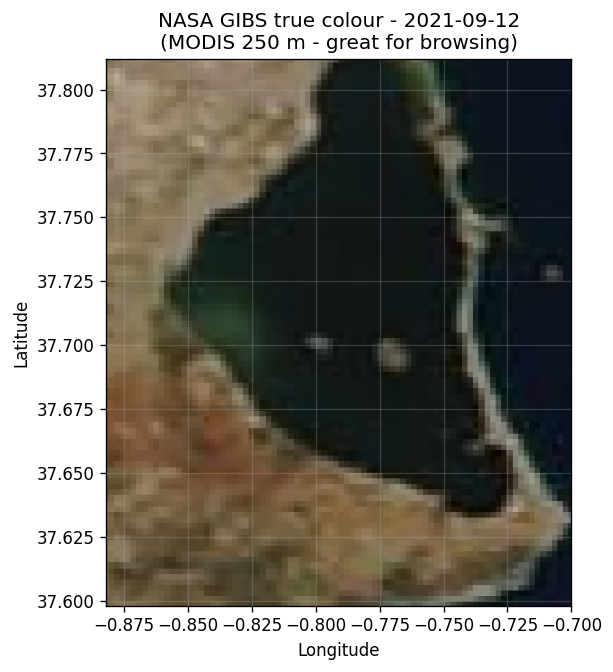

You just downloaded and displayed a real satellite image. No login needed.


In [3]:
def gibs_truecolor(bbox, date, layer="MODIS_Terra_CorrectedReflectance_TrueColor",
                   width=512, height=600):
    """Download a true-colour PNG from NASA GIBS WMS (no credentials)."""
    # WMS 1.3.0 with EPSG:4326 expects BBOX as lat_min,lon_min,lat_max,lon_max
    url = ("https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi?"
           "SERVICE=WMS&REQUEST=GetMap&VERSION=1.3.0"
           f"&LAYERS={layer}&CRS=EPSG:4326"
           f"&BBOX={bbox[1]},{bbox[0]},{bbox[3]},{bbox[2]}"
           f"&WIDTH={width}&HEIGHT={height}&FORMAT=image/png&TIME={date}")
    r = requests.get(url, timeout=30); r.raise_for_status()
    return mpimg.imread(io.BytesIO(r.content), format="png")

DATE = "2021-09-12"      # <-- try changing this date and re-running
if ONLINE:
    try:
        print(f"Requesting GIBS true-colour image for {DATE} ...")
        img = gibs_truecolor(BBOX, DATE)
        print(f"  Received an image of shape {img.shape} (rows, cols, RGBA).")
        fig, ax = plt.subplots(figsize=(5, 6))
        ax.imshow(img, extent=[BBOX[0], BBOX[2], BBOX[1], BBOX[3]])
        ax.set_title(f"NASA GIBS true colour - {DATE}\n(MODIS 250 m - great for browsing)")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        plt.show()
        print("You just downloaded and displayed a real satellite image. No login needed.")
    except Exception as e:
        print("GIBS request failed:", e)
else:
    print("Offline - skipping the live GIBS download.")


### 1.2 LIVE — high-resolution Sentinel-2 from the cloud (STAC + COG)
GIBS is quick but coarse (250 m). For analysis we want **Sentinel-2 at 10 m**.
We will do this the modern, scalable way and **watch each step**:

1. **Search** a public catalogue (STAC) for scenes over our box → a results table.
2. **Pick** the clearest scene → look at its assets (the downloadable bands).
3. **Inspect** the cloud-optimised GeoTIFF (COG) *without downloading it* — just
   read its header (size, projection).
4. **Download only the AOI window** — a few MB instead of ~800 MB.
5. **Show** the array that arrived and render it.

This is the single most important skill in the module: pulling *just the pixels
you need* from a multi-terabyte archive.


In [4]:
def search_scenes_aws(bbox, start, end, max_cloud=20, limit=40):
    """STEP 1 - discover Sentinel-2 L2A scenes via public Earth Search STAC."""
    body = {"collections": ["sentinel-s2-l2a-cogs"], "bbox": list(bbox),
            "datetime": f"{start}/{end}",
            "query": {"eo:cloud_cover": {"lt": max_cloud}}, "limit": limit}
    r = requests.post("https://earth-search.aws.element84.com/v0/search",
                      json=body, timeout=30); r.raise_for_status()
    rows = []
    for f in r.json().get("features", []):
        p = f["properties"]
        rows.append({"scene_id": f["id"], "date": p["datetime"][:10],
                     "cloud_pct": round(p.get("eo:cloud_cover", -1), 1),
                     "tile": f["id"].split("_")[1],
                     "assets": f["assets"]})
    return pd.DataFrame(rows)

if ONLINE:
    try:
        print("STEP 1  Searching the catalogue (live)...")
        scenes = search_scenes_aws(BBOX, "2021-09-01", "2021-09-30")
        scenes = scenes[scenes["tile"] == "30SXG"].sort_values("cloud_pct").reset_index(drop=True)
        print(f"        Found {len(scenes)} scenes over tile 30SXG in Sep 2021:")
        print(scenes[["scene_id", "date", "cloud_pct"]].to_string(index=False))

        best = scenes.iloc[0]
        print(f"\nSTEP 2  Clearest scene: {best.scene_id} ({best.cloud_pct}% cloud)")
        print(f"        Available bands: {sorted(best.assets.keys())[:12]} ...")
    except Exception as e:
        print("Live search failed:", e); scenes = None
else:
    print("Offline - skipping live STAC search."); scenes = None


STEP 1  Searching the catalogue (live)...


        Found 2 scenes over tile 30SXG in Sep 2021:
                scene_id       date  cloud_pct
S2A_30SXG_20210912_0_L2A 2021-09-12        0.0
S2B_30SXG_20210917_0_L2A 2021-09-17        0.9

STEP 2  Clearest scene: S2A_30SXG_20210912_0_L2A (0.0% cloud)
        Available bands: ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12'] ...


STEP 3  Opening the COG header (no pixels downloaded yet)...


        Full scene: 10980 x 10980 px, CRS EPSG:32630, 1 band, dtype uint16
STEP 4  Reading only the AOI window 1660 x 2412 px ...


        Downloaded ~8.0 MB instead of ~241 MB in 2.6s (3.3% of the scene).
STEP 5  Array received: shape (2413, 1661), reflectance range 22-3212 DN


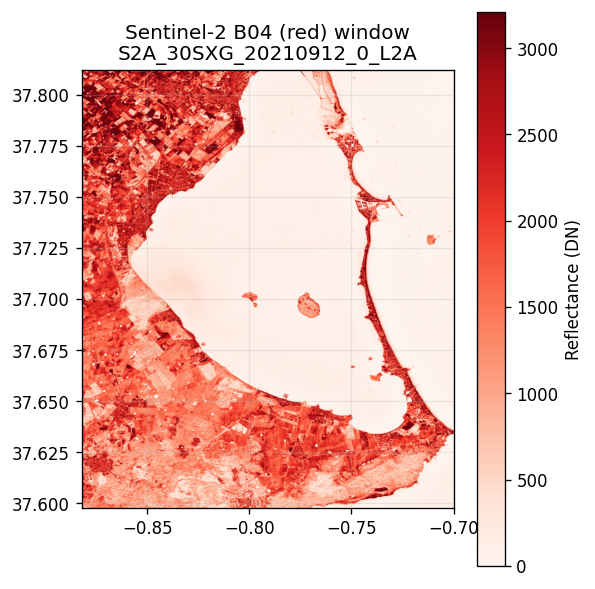

That is a live, windowed download from a multi-TB archive.


In [5]:
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds

if ONLINE and scenes is not None and len(scenes):
    try:
        b04_href = best.assets["B04"]["href"]      # red band COG on S3
        print("STEP 3  Opening the COG header (no pixels downloaded yet)...")
        with rasterio.open(b04_href) as src:
            print(f"        Full scene: {src.width} x {src.height} px, CRS {src.crs}, "
                  f"{src.count} band, dtype {src.dtypes[0]}")
            # STEP 4 - read ONLY our AOI window
            aoi_utm = transform_bounds("EPSG:4326", src.crs, *BBOX)
            win = from_bounds(*aoi_utm, transform=src.transform)
            print(f"STEP 4  Reading only the AOI window {int(win.width)} x {int(win.height)} px ...")
            t0 = time.time()
            red = src.read(1, window=win).astype(float)
            dt = time.time() - t0
        full_mb = src.width * src.height * 2 / 1e6
        win_mb  = red.size * 2 / 1e6
        print(f"        Downloaded ~{win_mb:.1f} MB instead of ~{full_mb:.0f} MB "
              f"in {dt:.1f}s ({100*win_mb/full_mb:.1f}% of the scene).")
        print(f"STEP 5  Array received: shape {red.shape}, "
              f"reflectance range {np.nanpercentile(red,2):.0f}-{np.nanpercentile(red,98):.0f} DN")

        fig, ax = plt.subplots(figsize=(5, 6))
        im = ax.imshow(red, cmap="Reds", extent=[BBOX[0], BBOX[2], BBOX[1], BBOX[3]],
                       vmin=0, vmax=np.nanpercentile(red, 98))
        ax.set_title(f"Sentinel-2 B04 (red) window\n{best.scene_id}")
        plt.colorbar(im, ax=ax, label="Reflectance (DN)"); plt.show()
        print("That is a live, windowed download from a multi-TB archive.")
    except Exception as e:
        print("Live COG read failed (network/quota):", e)
else:
    print("Offline - the cached GeoTIFFs in data/ already hold these windows.")


### 1.3 LIVE — pollution data for the lagoon (Open-Meteo Air-Quality)
Satellites are not the only free data. The **Open-Meteo Air-Quality API** returns
hourly **PM2.5, PM10, ozone** for any coordinate — no key. This is direct
*pollution* context: dust and aerosols over the Campo de Cartagena tie into the
nutrient runoff story. One GET request returns JSON, which becomes a DataFrame.


Requesting hourly air quality at the lagoon (live)...


  Received 192 hourly rows. Latest values:
               time  pm10  pm2_5  ozone
2026-06-04 23:00:00  33.0   15.6   78.0


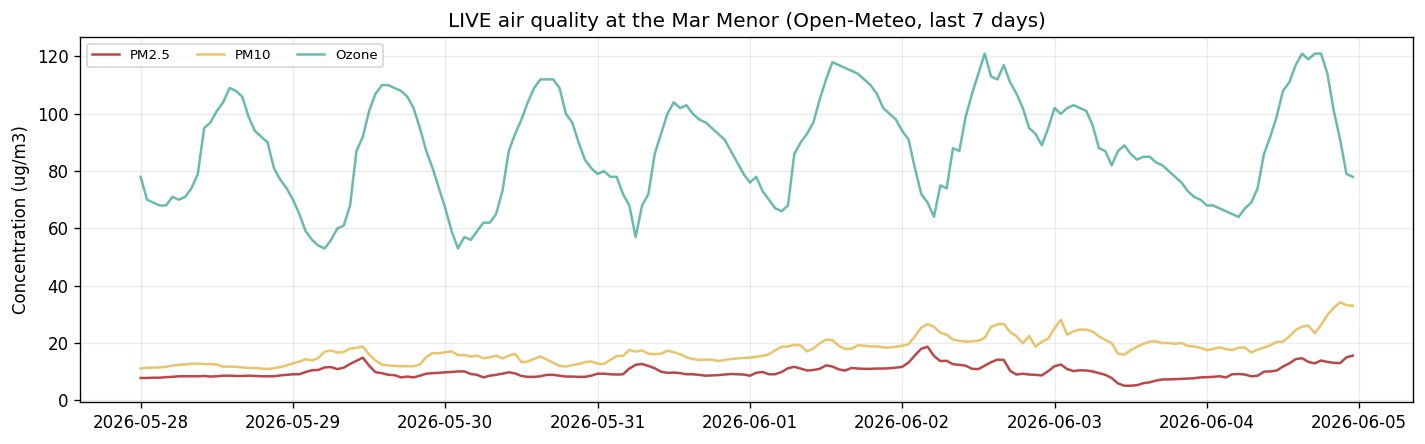

In [6]:
def open_meteo_air_quality(lat, lon, past_days=7):
    url = ("https://air-quality-api.open-meteo.com/v1/air-quality?"
           f"latitude={lat}&longitude={lon}"
           "&hourly=pm10,pm2_5,ozone&past_days=" + str(past_days) + "&forecast_days=1")
    r = requests.get(url, timeout=30); r.raise_for_status()
    h = r.json()["hourly"]
    df = pd.DataFrame(h); df["time"] = pd.to_datetime(df["time"]); return df

if ONLINE:
    try:
        print("Requesting hourly air quality at the lagoon (live)...")
        aq = open_meteo_air_quality(LAGOON_LAT, LAGOON_LON)
        print(f"  Received {len(aq)} hourly rows. Latest values:")
        print(aq.tail(1).to_string(index=False))
        fig, ax = plt.subplots(figsize=(12, 3.8))
        ax.plot(aq["time"], aq["pm2_5"], label="PM2.5", color="#bc4749")
        ax.plot(aq["time"], aq["pm10"],  label="PM10",  color="#e9c46a")
        ax.plot(aq["time"], aq["ozone"], label="Ozone", color="#2a9d8f", alpha=0.7)
        ax.set_ylabel("Concentration (ug/m3)")
        ax.set_title("LIVE air quality at the Mar Menor (Open-Meteo, last 7 days)")
        ax.legend(fontsize=8, ncol=3); fig.tight_layout(); plt.show()
    except Exception as e:
        print("Air-quality request failed:", e)
else:
    print("Offline - skipping live air-quality download.")


### 1.4 LIVE — sea-surface temperature time series (Open-Meteo Marine)
The **Open-Meteo Marine API** gives hourly **sea-surface temperature** for a
coordinate — a free, instant complement to the Sentinel-3 SST cube of Module 1.
Same pattern: GET → JSON → DataFrame → plot.


Requesting hourly SST near the lagoon mouth (live)...


  Received 264 valid hourly SST values, latest = 21.5 degC


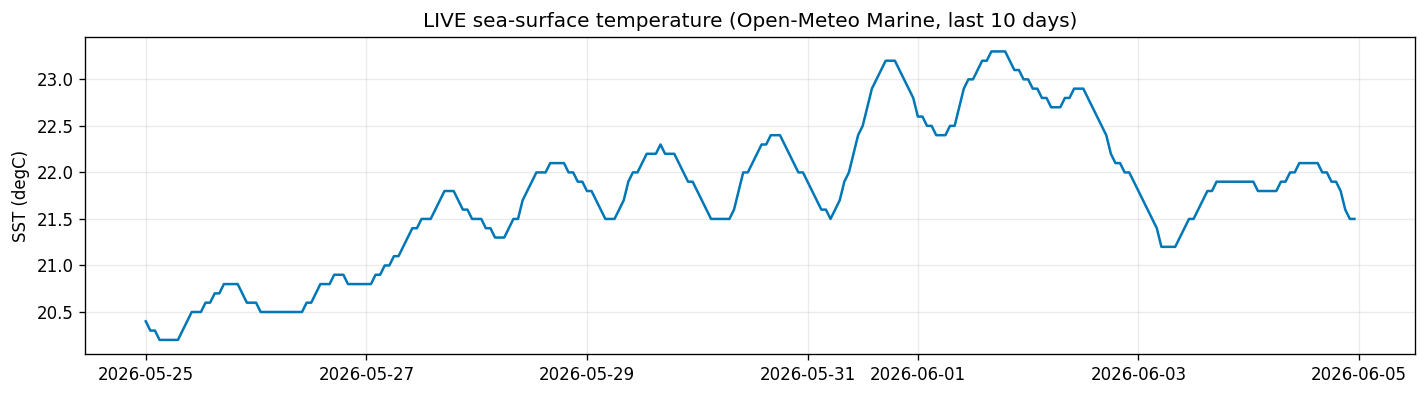

In [7]:
def open_meteo_sst(lat, lon, past_days=10):
    url = ("https://marine-api.open-meteo.com/v1/marine?"
           f"latitude={lat}&longitude={lon}"
           "&hourly=sea_surface_temperature&past_days=" + str(past_days) + "&forecast_days=1")
    r = requests.get(url, timeout=30); r.raise_for_status()
    h = r.json()["hourly"]
    df = pd.DataFrame(h); df["time"] = pd.to_datetime(df["time"]); return df

if ONLINE:
    try:
        print("Requesting hourly SST near the lagoon mouth (live)...")
        sst = open_meteo_sst(37.65, -0.75)
        good = sst.dropna(subset=["sea_surface_temperature"])
        print(f"  Received {len(good)} valid hourly SST values, "
              f"latest = {good['sea_surface_temperature'].iloc[-1]:.1f} degC")
        fig, ax = plt.subplots(figsize=(12, 3.4))
        ax.plot(good["time"], good["sea_surface_temperature"], color="#0077b6")
        ax.set_ylabel("SST (degC)")
        ax.set_title("LIVE sea-surface temperature (Open-Meteo Marine, last 10 days)")
        fig.tight_layout(); plt.show()
    except Exception as e:
        print("Marine request failed:", e)
else:
    print("Offline - skipping live SST download.")


### 1.5 Level up: get a *free* Copernicus account — do it now, live
The open sources are great for prototyping. A **free Copernicus Data Space
Ecosystem (CDSE) account** unlocks what the AWS mirror cannot: **server-side,
on-demand processing**. You send a small script and CDSE returns *exactly the
product you ask for* — for any date, any area — and even full **time series
without downloading a single image**.

**Let's set it up together in class — about 3 minutes:**

### ① Register  →  <https://dataspace.copernicus.eu>
Click **“Register”** (top right), enter your email + password, accept the terms,
confirm the verification email. Done — free, no credit card, ~30,000 processing
units/month.

### ② Create an OAuth client (your "API key")
1. Log in and open the **Sentinel Hub dashboard**: <https://shapps.dataspace.copernicus.eu/dashboard/>
2. **User settings → OAuth clients → “Create new”**.
3. It shows you a **Client ID** and a **Client secret**. ⚠️ The secret is shown
   **only once** — copy it now.

### ③ Paste them into the next cell when you run it
Run the cell below. It will prompt you to **paste your Client ID and Client
secret** (the secret box is hidden as you type/paste). It then logs in and gets
an access token — and every CDSE cell after it runs live, on your own account.

> 🔒 Your secret is read into memory only, never written into the notebook. If
> you skip this (just press Enter), the rest of the section still shows the code
> patterns without running.

> ✏️ **EDIT** — run the cell below and paste your Client ID + secret when prompted.


In [8]:
import os, getpass

def cdse_token(client_id, client_secret):
    """Exchange OAuth client credentials for a CDSE access token."""
    r = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/"
        "protocol/openid-connect/token",
        data={"grant_type": "client_credentials",
              "client_id": client_id, "client_secret": client_secret},
        timeout=30)
    r.raise_for_status()
    return r.json()["access_token"]

# Credentials come from (1) environment variables if set, else (2) a live prompt.
CID  = os.environ.get("CDSE_CLIENT_ID")
CSEC = os.environ.get("CDSE_CLIENT_SECRET")
if not (CID and CSEC):
    try:
        print("Paste your CDSE OAuth credentials (or just press Enter to skip):")
        CID  = input("  Client ID:     ").strip()
        CSEC = getpass.getpass("  Client secret: ").strip()   # hidden input
    except Exception:
        # Non-interactive execution (e.g. building the HTML) - skip the prompt.
        CID = CSEC = ""

TOKEN = None
if CID and CSEC:
    try:
        TOKEN = cdse_token(CID, CSEC)
        print("\nAuthenticated with CDSE - token acquired (valid ~10 min).")
        print("The cells below will now run LIVE against your account.")
    except Exception as e:
        print("Authentication failed:", e)
else:
    print("No credentials entered - skipping live CDSE calls.")
    print("Register at dataspace.copernicus.eu, create an OAuth client, then")
    print("re-run this cell and paste them. The cells below show the patterns meanwhile.")



Authenticated with CDSE - token acquired (valid ~10 min).
The cells below will now run LIVE against your account.


### What you unlock #1 — on-demand products with the **Process API**

You send an **evalscript** (a tiny JS function describing the output you want) plus
a bounding box and date range; CDSE runs it server-side and returns a ready array.
Here we ask for an **NDCI** chlorophyll map directly — no band downloads, no
mosaicking. Swap the evalscript for a C2RCC one and you get true Case-2 chl-a.


Requesting an on-demand NDCI map from CDSE (live)...


  Received an NDCI array (300, 256), median +0.038


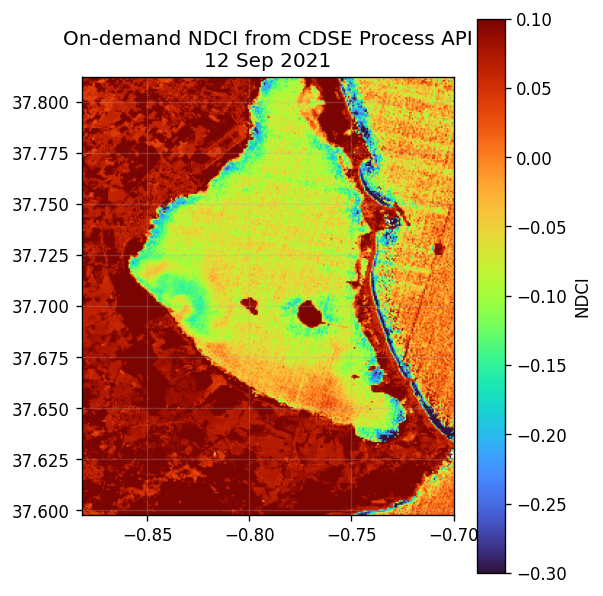

CDSE computed this server-side and sent only the result.


In [9]:
PROCESS_URL = "https://sh.dataspace.copernicus.eu/api/v1/process"

# An evalscript is just "what do I want each pixel to be?". This one = NDCI.
EVALSCRIPT_NDCI = """//VERSION=3
function setup() {
  return { input: ["B04", "B05", "dataMask"],
           output: { bands: 2, sampleType: "FLOAT32" } };
}
function evaluatePixel(s) {
  let ndci = (s.B05 - s.B04) / (s.B05 + s.B04);
  return [ndci, s.dataMask];
}"""

def process_ndci(token, bbox, date, size=(256, 300)):
    body = {
        "input": {
            "bounds": {"bbox": list(bbox),
                       "properties": {"crs": "http://www.opengis.net/def/crs/EPSG/0/4326"}},
            "data": [{"type": "sentinel-2-l2a",
                      "dataFilter": {"timeRange": {"from": f"{date}T00:00:00Z",
                                                   "to": f"{date}T23:59:59Z"}}}]},
        "output": {"width": size[0], "height": size[1],
                   "responses": [{"identifier": "default",
                                  "format": {"type": "image/tiff"}}]},
        "evalscript": EVALSCRIPT_NDCI}
    r = requests.post(PROCESS_URL, json=body,
                      headers={"Authorization": f"Bearer {token}"}, timeout=60)
    r.raise_for_status()
    return r.content        # GeoTIFF bytes

if TOKEN:
    try:
        print("Requesting an on-demand NDCI map from CDSE (live)...")
        tif = process_ndci(TOKEN, BBOX, "2021-09-12")
        with rasterio.open(io.BytesIO(tif)) as src:
            arr = src.read(1); mask = src.read(2)
        ndci_live = np.where(mask > 0, arr, np.nan)
        print(f"  Received an NDCI array {ndci_live.shape}, "
              f"median {np.nanmedian(ndci_live):+.3f}")
        fig, ax = plt.subplots(figsize=(5, 6))
        im = ax.imshow(ndci_live, cmap="turbo", vmin=-0.3, vmax=0.1,
                       extent=[BBOX[0], BBOX[2], BBOX[1], BBOX[3]])
        ax.set_title("On-demand NDCI from CDSE Process API\n12 Sep 2021")
        plt.colorbar(im, ax=ax, label="NDCI"); plt.show()
        print("CDSE computed this server-side and sent only the result.")
    except Exception as e:
        print("Process API call failed:", e)
else:
    print("[pattern] With a token this returns a ready-made NDCI GeoTIFF for any date.")
    print("          The evalscript above is the whole 'recipe' CDSE runs for you.")


### What you unlock #1b — the real **image** *and* the raw **band values**

The same Process API serves two needs from one place:
- a **rendered picture** (true-colour RGB) to drop into a report, and
- the **raw reflectance arrays** (the actual band numbers) to do your own science.

We pull both for 12 Sep 2021. From the raw bands we then plot the **spectral
signature** of the lagoon water — and you can literally *see* the chlorophyll: the
reflectance climbs into the red-edge (B05) instead of falling like clear ocean
water would.


Requesting a true-colour image from CDSE (live)...


  Received a (300, 256, 3) image.


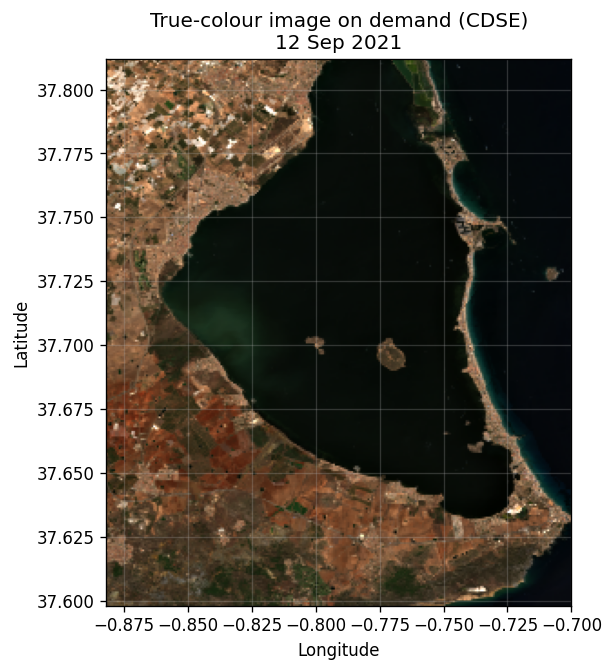

In [10]:
def sh_process(token, bbox, date, evalscript, fmt="image/tiff", size=(256, 300)):
    """Generic CDSE Process API call -> returns the raw bytes (PNG or GeoTIFF)."""
    body = {
        "input": {"bounds": {"bbox": list(bbox),
                  "properties": {"crs": "http://www.opengis.net/def/crs/EPSG/0/4326"}},
                  "data": [{"type": "sentinel-2-l2a",
                            "dataFilter": {"timeRange": {"from": f"{date}T00:00:00Z",
                                                         "to": f"{date}T23:59:59Z"}}}]},
        "output": {"width": size[0], "height": size[1],
                   "responses": [{"identifier": "default", "format": {"type": fmt}}]},
        "evalscript": evalscript}
    r = requests.post(PROCESS_URL, json=body,
                      headers={"Authorization": f"Bearer {token}"}, timeout=60)
    r.raise_for_status()
    return r.content

# Recipe A: a true-colour picture (gain 2.5 brings reflectance into 0-1 for display)
EVALSCRIPT_TRUECOLOR = """//VERSION=3
function setup() { return { input: ["B02","B03","B04"],
                            output: { bands: 3, sampleType: "AUTO" } }; }
function evaluatePixel(s) { return [2.5*s.B04, 2.5*s.B03, 2.5*s.B02]; }"""

if TOKEN:
    try:
        print("Requesting a true-colour image from CDSE (live)...")
        png = sh_process(TOKEN, BBOX, "2021-09-12", EVALSCRIPT_TRUECOLOR, fmt="image/png")
        img = mpimg.imread(io.BytesIO(png), format="png")
        print(f"  Received a {img.shape} image.")
        fig, ax = plt.subplots(figsize=(5, 6))
        ax.imshow(img, extent=[BBOX[0], BBOX[2], BBOX[1], BBOX[3]])
        ax.set_title("True-colour image on demand (CDSE)\n12 Sep 2021")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); plt.show()
    except Exception as e:
        print("True-colour request failed:", e)
else:
    print("[pattern] sh_process(token, BBOX, date, EVALSCRIPT_TRUECOLOR, fmt='image/png')")
    print("          returns a ready-to-show RGB picture for any date.")


Requesting the raw reflectance bands from CDSE (live)...


  Raw band values (mean surface reflectance over the lagoon):
band  wavelength_nm  mean_reflectance
 B02            490            0.0486
 B03            560            0.0698
 B04            665            0.0839
 B05            705            0.1001
 B08            842            0.1203


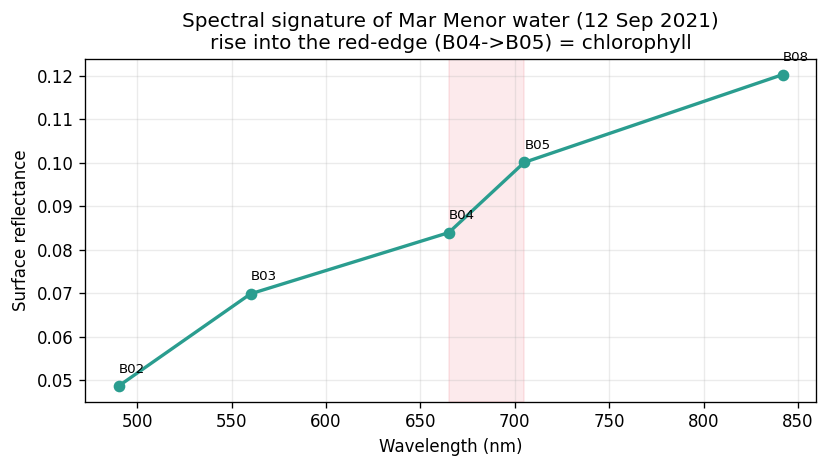

These are the actual numbers - feed them into any index or ML model.


In [11]:
# Recipe B: the raw surface-reflectance bands as a FLOAT32 stack
EVALSCRIPT_BANDS = """//VERSION=3
function setup() { return { input: ["B02","B03","B04","B05","B08","dataMask"],
                            output: { bands: 6, sampleType: "FLOAT32" } }; }
function evaluatePixel(s) { return [s.B02, s.B03, s.B04, s.B05, s.B08, s.dataMask]; }"""

BANDS_INFO = [("B02", 490), ("B03", 560), ("B04", 665), ("B05", 705), ("B08", 842)]

if TOKEN:
    try:
        print("Requesting the raw reflectance bands from CDSE (live)...")
        tif = sh_process(TOKEN, BBOX, "2021-09-12", EVALSCRIPT_BANDS, fmt="image/tiff")
        with rasterio.open(io.BytesIO(tif)) as src:
            stack = src.read()                  # (6, H, W): 5 bands + dataMask
        water = stack[5] > 0
        refl = {nm: float(np.mean(stack[i][water])) for i, (nm, _) in enumerate(BANDS_INFO)}
        tbl = pd.DataFrame({"band": [b for b, _ in BANDS_INFO],
                            "wavelength_nm": [w for _, w in BANDS_INFO],
                            "mean_reflectance": [round(refl[b], 4) for b, _ in BANDS_INFO]})
        print("  Raw band values (mean surface reflectance over the lagoon):")
        print(tbl.to_string(index=False))

        fig, ax = plt.subplots(figsize=(7, 4))
        wl = [w for _, w in BANDS_INFO]; ys = [refl[b] for b, _ in BANDS_INFO]
        ax.plot(wl, ys, "o-", color="#2a9d8f", lw=2)
        for (nm, w), y in zip(BANDS_INFO, ys):
            ax.annotate(nm, (w, y), textcoords="offset points", xytext=(0, 8), fontsize=8)
        ax.axvspan(665, 705, color="#e63946", alpha=0.10)
        ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Surface reflectance")
        ax.set_title("Spectral signature of Mar Menor water (12 Sep 2021)\n"
                     "rise into the red-edge (B04->B05) = chlorophyll")
        fig.tight_layout(); plt.show()
        print("These are the actual numbers - feed them into any index or ML model.")
    except Exception as e:
        print("Raw-band request failed:", e)
else:
    print("[pattern] The same call with EVALSCRIPT_BANDS + fmt='image/tiff' returns a")
    print("          6-band float array (B02,B03,B04,B05,B08,dataMask) to analyse yourself.")


### What you unlock #2 — a full time series with **no downloads** (Statistical API)

This is the real game-changer for monitoring. The **Statistical API** computes
statistics (mean, stdev, percentiles) over your AOI for **every date in a range**
and returns a small JSON — you never download a single image. A multi-year chl-a
time series becomes *one request*.


Requesting a 2021 NDCI time series over the AOI (no image downloads)...


  One request -> 15 dates, zero images downloaded:
      date  ndci_mean
2021-06-01   0.070441
2021-06-11   0.014287
2021-06-21   0.038714
2021-07-01   0.034886
2021-07-11   0.043056
2021-07-21   0.033962
2021-07-31   0.041631
2021-08-10   0.050540
2021-08-20   0.049713
2021-08-30   0.053757
2021-09-09   0.029297
2021-09-19   0.029713
2021-09-29   0.034730
2021-10-09   0.039701
2021-10-19   0.006854


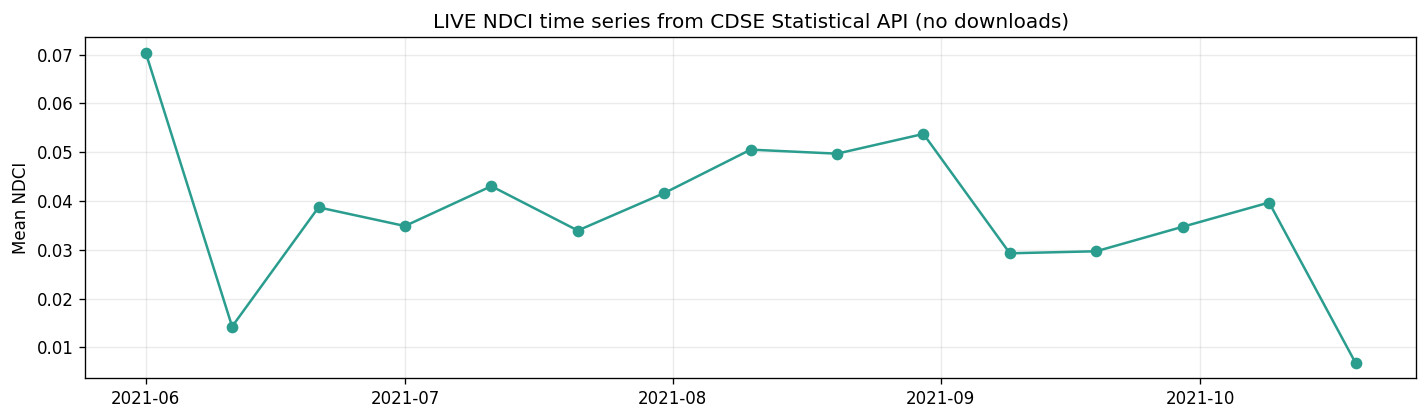

In [12]:
STATS_URL = "https://sh.dataspace.copernicus.eu/api/v1/statistics"

# The Statistical API requires NAMED outputs, including a dedicated 'dataMask'.
EVALSCRIPT_STATS = """//VERSION=3
function setup() {
  return { input: ["B04", "B05", "dataMask"],
           output: [ { id: "ndci", bands: 1, sampleType: "FLOAT32" },
                     { id: "dataMask", bands: 1 } ] };
}
function evaluatePixel(s) {
  let ndci = (s.B05 - s.B04) / (s.B05 + s.B04);
  return { ndci: [ndci], dataMask: [s.dataMask] };
}"""

def stats_ndci(token, bbox, start, end, interval="P10D"):
    body = {
        "input": {"bounds": {"bbox": list(bbox),
                  "properties": {"crs": "http://www.opengis.net/def/crs/EPSG/0/4326"}},
                  "data": [{"type": "sentinel-2-l2a"}]},
        "aggregation": {
            "timeRange": {"from": f"{start}T00:00:00Z", "to": f"{end}T23:59:59Z"},
            "aggregationInterval": {"of": interval},   # one value every 10 days
            "evalscript": EVALSCRIPT_STATS,
            "resx": 0.0002, "resy": 0.0002},
    }
    r = requests.post(STATS_URL, json=body,
                      headers={"Authorization": f"Bearer {token}"}, timeout=90)
    r.raise_for_status()
    return r.json()

if TOKEN:
    try:
        print("Requesting a 2021 NDCI time series over the AOI (no image downloads)...")
        js = stats_ndci(TOKEN, BBOX, "2021-06-01", "2021-10-31")
        recs = []
        for item in js.get("data", []):
            t = item["interval"]["from"][:10]
            out = item.get("outputs", {}).get("ndci")
            if out:
                recs.append({"date": t,
                             "ndci_mean": out["bands"]["B0"]["stats"].get("mean")})
        ts = pd.DataFrame(recs)
        print(f"  One request -> {len(ts)} dates, zero images downloaded:")
        print(ts.to_string(index=False))
        good = ts.dropna(subset=["ndci_mean"])
        if len(good):
            fig, ax = plt.subplots(figsize=(12, 3.6))
            ax.plot(pd.to_datetime(good["date"]), good["ndci_mean"],
                    "o-", color="#2a9d8f")
            ax.set_ylabel("Mean NDCI"); ax.set_title(
                "LIVE NDCI time series from CDSE Statistical API (no downloads)")
            fig.tight_layout(); plt.show()
    except Exception as e:
        print("Statistical API call failed:", e)
else:
    print("[pattern] With a token, one request returns mean NDCI every 10 days,")
    print("          for years if you want - and you download zero imagery.")
    print("          This is how you build a monitoring dashboard cheaply.")


### 1.6 Other free-account sources (reference)

> ⏭️ **OPTIONAL** — reference snippets for later; nothing to run here.

Three more archives worth a free account when your project needs them:

**Copernicus Marine (CMEMS)** — multi-year ocean physics + biogeochemistry reanalysis:

```python
# pip install copernicusmarine ; copernicusmarine login   (free account)
import copernicusmarine as cm
ds = cm.open_dataset(dataset_id="MEDSEA_ANALYSISFORECAST_BGC_006_014",
    minimum_longitude=AOI["lon_min"], maximum_longitude=AOI["lon_max"],
    minimum_latitude=AOI["lat_min"],  maximum_latitude=AOI["lat_max"],
    start_datetime="2021-08-01", end_datetime="2021-09-30", variables=["chl"])
```

**NASA Earthdata** — MODIS/VIIRS ocean colour, HLS (free Earthdata login):

```python
# pip install earthaccess ; earthaccess.login()
import earthaccess
g = earthaccess.search_data(short_name="MODISA_L3m_CHL", bounding_box=BBOX,
                            temporal=("2021-08-01", "2021-09-30"))
earthaccess.download(g, "./modis_chl")
```

**EMODnet** — EU coastal bathymetry / chemistry via OGC `WMS`/`WFS`/`ERDDAP`
(no login); ideal as context layers in QGIS.

> The take-away holds for every source — **discover → request a subset → get an
> array/table** — and Parts 2–5 below treat them all the same.


---
## Part 2 — Clean & QA: which pixels can you trust?
Raw pixels are **not** observations. A scene can be cloudy, or only clip the edge
of a satellite pass. Before storing anything we (1) keep only **water** pixels,
(2) drop **clouds**, and (3) score each scene's **coverage and cloud fraction over
the lagoon** so we can reject bad ones. This is exactly why the 14-Jul-2021 scene
was rejected in Module 1 (only 5.5 % coverage — a swath edge).

We work from the four cached, validated scenes (`data/s2_*`).


In [13]:
# Water mask in image coordinates (row 0 = North)
_H, _W = 2140, 1800
_rows = np.linspace(AOI["lat_max"], AOI["lat_min"], _H)
_cols = np.linspace(AOI["lon_min"], AOI["lon_max"], _W)
_CC, LAT2D = np.meshgrid(_cols, _rows)
WATER_MASK = (MplPath(LAGOON_POLY).contains_points(
    np.column_stack([_CC.ravel(), LAT2D.ravel()])).reshape(_H, _W)
    if LAGOON_POLY is not None else np.zeros((_H, _W), bool))

def load_band(scene, band):
    with rasterio.open(DATA / f"s2_{scene}_{band}.tif") as src:
        return src.read(1).astype(np.float32)

def qa_scene(scene):
    """Coverage% and cloud% over the lagoon (cloud proxy: bright red over water)."""
    b04 = load_band(scene, "B04"); in_lag = b04[WATER_MASK]; valid = in_lag > 0
    coverage = 100 * valid.sum() / in_lag.size
    cloud    = 100 * (in_lag[valid] > 800).sum() / max(valid.sum(), 1)
    return round(coverage, 1), round(cloud, 1)

SCENES = {"baseline": ("2020-02-10", "S2A", "30SXG"),
          "bloom":    ("2021-08-18", "S2B", "30SXG"),
          "peak":     ("2021-09-12", "S2A", "30SXG"),
          "recovery": ("2022-03-01", "S2A", "30SXG")}

REAL = list(DATA.glob("s2_*_TCI.tif"))
HAVE_REAL = len(REAL) >= 4 and LAGOON_POLY is not None
if HAVE_REAL:
    qa = pd.DataFrame([
        {"scene_key": k, "date": d, "mission": m, "tile": t,
         "coverage_pct": qa_scene(k)[0], "cloud_pct_aoi": qa_scene(k)[1],
         "qa_pass": (qa_scene(k)[0] > 98) and (qa_scene(k)[1] < 10)}
        for k, (d, m, t) in SCENES.items()])
    print("Per-scene QA over the lagoon (qa_pass = keep it):")
    print(qa.to_string(index=False))
else:
    qa = pd.DataFrame()
    print("Real GeoTIFFs not downloaded - run scripts/download_sentinel2.py for Parts 2-4.")
    print("(The synthetic series below still lets you build and query the database.)")


Per-scene QA over the lagoon (qa_pass = keep it):
scene_key       date mission  tile  coverage_pct  cloud_pct_aoi  qa_pass
 baseline 2020-02-10     S2A 30SXG         100.0            0.6     True
    bloom 2021-08-18     S2B 30SXG         100.0            1.4     True
     peak 2021-09-12     S2A 30SXG         100.0            1.1     True
 recovery 2022-03-01     S2A 30SXG         100.0            1.0     True


---
## Part 3 — Extract: turn clean pixels into tidy numbers
A database wants **tidy, long-format** rows: one row per *(date, variable, zone,
value)*. That shape makes everything downstream — filtering, grouping, joining —
a one-liner. We compute the **NDCI** chlorophyll index per scene and summarise it
for the whole lagoon and per latitude zone (North / Centre / South).


In [14]:
def compute_ndci(scene):
    b05 = load_band(scene, "B05"); b04 = load_band(scene, "B04")
    valid = WATER_MASK & (b04 > 30) & (b05 > 30) & (b04 < 800)
    ndci = np.where(valid, (b05 - b04) / np.maximum(b05 + b04, 1), np.nan)
    return np.ma.array(ndci, mask=~valid)

ZONES = {"north":  LAT2D > 37.72,
         "centre": (LAT2D <= 37.72) & (LAT2D > 37.66),
         "south":  LAT2D <= 37.66}

obs_rows = []
if HAVE_REAL:
    for key, (date, mission, tile) in SCENES.items():
        ndci = compute_ndci(key)
        # whole lagoon
        obs_rows.append({"date": date, "source": "sentinel2_real", "variable": "ndci",
                         "zone": "all", "value": round(float(np.ma.median(ndci)), 4),
                         "units": "index", "n_pixels": int((~ndci.mask).sum()),
                         "scene_id": f"S2_{key}", "qa_flag": "ok"})
        for zone, zmask in ZONES.items():
            sel = zmask & ~ndci.mask
            if sel.sum():
                obs_rows.append({"date": date, "source": "sentinel2_real",
                    "variable": "ndci", "zone": zone,
                    "value": round(float(np.ma.median(ndci[sel])), 4), "units": "index",
                    "n_pixels": int(sel.sum()), "scene_id": f"S2_{key}", "qa_flag": "ok"})
    obs_real = pd.DataFrame(obs_rows)
    print(f"Extracted {len(obs_real)} tidy rows from {len(SCENES)} real scenes. Sample:")
    print(obs_real.head(6).to_string(index=False))
else:
    obs_real = pd.DataFrame()
    print("No real imagery - tidy table comes from the synthetic series only.")


Extracted 16 tidy rows from 4 real scenes. Sample:
      date         source variable   zone   value units  n_pixels    scene_id qa_flag
2020-02-10 sentinel2_real     ndci    all -0.2789 index    324466 S2_baseline      ok
2020-02-10 sentinel2_real     ndci  north -0.2706 index    175518 S2_baseline      ok
2020-02-10 sentinel2_real     ndci centre -0.3143 index    128115 S2_baseline      ok
2020-02-10 sentinel2_real     ndci  south -0.1349 index     20833 S2_baseline      ok
2021-08-18 sentinel2_real     ndci    all -0.0068 index   1335037    S2_bloom      ok
2021-08-18 sentinel2_real     ndci  north -0.0108 index    651041    S2_bloom      ok


### The long historical series (so we can study a *trend*)

Four scenes show spatial detail but cannot give a multi-year trend. In a real
project you would loop Parts 1–3 over **hundreds** of scenes. To keep the lesson
runnable we load a pre-computed **synthetic** lagoon-mean chl-a series (2017–2025)
in the same tidy shape, tagged `source = "sentinel2_synthetic"` so provenance is
always explicit.


In [15]:
s2 = pd.read_parquet(DATA / "sentinel2_waterquality.parquet").assign(
    date=lambda d: pd.to_datetime(d["date"]))
series = s2.groupby("date")["chla_mg_m3"].mean().reset_index()
obs_series = pd.DataFrame({
    "date": series["date"].dt.strftime("%Y-%m-%d"), "source": "sentinel2_synthetic",
    "variable": "chla_mg_m3", "zone": "all", "value": series["chla_mg_m3"].round(3),
    "units": "mg_m3", "n_pixels": 12, "scene_id": None, "qa_flag": "ok"})

observations = pd.concat([obs_real, obs_series], ignore_index=True)
print(f"Total tidy observations to store: {len(observations):,}")
print(observations["source"].value_counts().to_string())


Total tidy observations to store: 421
source
sentinel2_synthetic    405
sentinel2_real          16


---
## Part 4 — Store it the right way (SQLite + Parquet)
### Why a database and not a pile of CSVs?

Once you have more than a handful of files, CSVs become a swamp: no types, no
keys, no fast filtering, easy to duplicate. A **database** gives you typed
columns, primary keys (no accidental duplicates), indices (fast queries) and SQL.

We use the **SQLite + Parquet hybrid**:
- **SQLite** (one `.db` file, zero install): the catalogue + tidy observations — everything you *query*.
- **Parquet**: the bulky per-pixel arrays — everything you *bulk-read*.

### 4.1 Design the schema
Three tables, each with a primary key and indices on what we filter by. The
`UNIQUE(date, source, variable, zone)` constraint is the magic that makes re-runs
**idempotent**: `INSERT OR REPLACE` updates a row instead of duplicating it.


In [16]:
SCHEMA = """
CREATE TABLE IF NOT EXISTS scenes (
    scene_id TEXT PRIMARY KEY, date TEXT NOT NULL, mission TEXT, tile TEXT,
    coverage_pct REAL, cloud_pct_aoi REAL, qa_pass INTEGER
);
CREATE TABLE IF NOT EXISTS observations (
    obs_id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT NOT NULL, source TEXT NOT NULL, variable TEXT NOT NULL,
    zone TEXT NOT NULL, value REAL, units TEXT, n_pixels INTEGER,
    scene_id TEXT, qa_flag TEXT,
    UNIQUE(date, source, variable, zone)
);
CREATE TABLE IF NOT EXISTS stations (
    station_id TEXT PRIMARY KEY, name TEXT, lon REAL, lat REAL, depth_m REAL
);
CREATE INDEX IF NOT EXISTS ix_obs_date ON observations(date);
CREATE INDEX IF NOT EXISTS ix_obs_var  ON observations(variable);
"""
con = sqlite3.connect(DB_PATH)
con.executescript(SCHEMA); con.commit()
print("Schema created in", DB_PATH.name)
print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con).to_string(index=False))


Schema created in marmenor.db
           name
         scenes
   observations
sqlite_sequence
       stations


### 4.2 Load the tables (idempotent inserts)
`INSERT OR REPLACE` means you can re-run this cell a hundred times and the row
count never grows — exactly what a scheduled, incremental pipeline needs.


In [17]:
if not qa.empty:
    for _, r in qa.iterrows():
        con.execute("INSERT OR REPLACE INTO scenes "
            "(scene_id,date,mission,tile,coverage_pct,cloud_pct_aoi,qa_pass) VALUES (?,?,?,?,?,?,?)",
            (f"S2_{r.scene_key}", r.date, r.mission, r.tile,
             r.coverage_pct, r.cloud_pct_aoi, int(r.qa_pass)))

for _, r in observations.iterrows():
    con.execute("INSERT OR REPLACE INTO observations "
        "(date,source,variable,zone,value,units,n_pixels,scene_id,qa_flag) VALUES (?,?,?,?,?,?,?,?,?)",
        (r.date, r.source, r.variable, r.zone, r.value, r.units,
         int(r.n_pixels), r.scene_id, r.qa_flag))

stations = pd.read_csv(DATA / "stations.csv")
for _, r in stations.iterrows():
    con.execute("INSERT OR REPLACE INTO stations (station_id,name,lon,lat,depth_m) VALUES (?,?,?,?,?)",
        (r["station_id"], r.get("name", r["station_id"]),
         float(r["lon"]), float(r["lat"]), float(r["depth_m"])))
con.commit()

for t in ["scenes", "observations", "stations"]:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"  {t:14s}: {n:,} rows")


  scenes        : 4 rows
  observations  : 421 rows
  stations      : 5 rows


### 4.3 Bulk arrays → Parquet (keep them out of the database)
Storing millions of pixels as SQL rows is the wrong tool. We save the per-pixel
NDCI field as compressed **Parquet** and keep only a *reference* in the database.


In [18]:
if HAVE_REAL:
    ndci_peak = compute_ndci("peak"); sel = ~ndci_peak.mask
    px = pd.DataFrame({"date": "2021-09-12",
                       "lon": _CC[sel].astype("float32"),
                       "lat": LAT2D[sel].astype("float32"),
                       "ndci": ndci_peak[sel].astype("float32")})
    pq = DB_DIR / "rasters" / "ndci_2021-09-12.parquet"
    px.to_parquet(pq, index=False)
    print(f"Wrote {len(px):,} pixels -> {pq.name} ({pq.stat().st_size/1e6:.1f} MB).")
    print("The database stores the path + metadata; the pixels live in Parquet.")
else:
    print("No real imagery - skipping the Parquet raster demo.")


Wrote 1,302,456 pixels -> ndci_2021-09-12.parquet (3.7 MB).
The database stores the path + metadata; the pixels live in Parquet.


---
## Part 5 — Analyse: a pollution study, straight from SQL
Everything is in the database now, so monitoring questions become short SQL
queries. We will (a) pull a monthly chl-a series, (b) fit a robust trend, (c)
count "poor status" exceedances, and (d) join satellite with in-situ — the kind
of figures that go into a status report.


In [19]:
# (a) Monthly-mean chl-a directly in SQL
monthly = pd.read_sql("""
    SELECT substr(date,1,7) AS month, AVG(value) AS chla
    FROM observations WHERE variable='chla_mg_m3' AND zone='all'
    GROUP BY month ORDER BY month
""", con)
monthly["t"] = pd.to_datetime(monthly["month"] + "-15")
print(f"{len(monthly)} monthly values, {monthly['t'].min():%Y-%m} to {monthly['t'].max():%Y-%m}")

# (b) Robust trend (Theil-Sen, resistant to bloom spikes)
from scipy.stats import theilslopes
x = (monthly["t"] - monthly["t"].min()).dt.days.values / 365.25
slope, intercept, lo, hi = theilslopes(monthly["chla"].values, x)
print(f"Long-term trend: {slope:+.3f} mg/m3 per year (90% CI {lo:+.3f}..{hi:+.3f})")

# (c) 'Poor status' exceedance per year (teaching threshold)
THR = 5.0
exc = pd.read_sql(f"""
    SELECT substr(date,1,4) AS year,
           SUM(CASE WHEN value > {THR} THEN 1 ELSE 0 END) AS exceed,
           COUNT(*) AS n
    FROM observations WHERE variable='chla_mg_m3' AND zone='all'
    GROUP BY year ORDER BY year
""", con)
exc["pct"] = (100 * exc["exceed"] / exc["n"]).round(1)
print("\n% of observations above", THR, "mg/m3 by year:")
print(exc[["year","exceed","n","pct"]].to_string(index=False))


107 monthly values, 2017-01 to 2025-12


Long-term trend: +0.023 mg/m3 per year (90% CI -0.023..+0.095)

% of observations above 5.0 mg/m3 by year:
year  exceed  n  pct
2017       0 41  0.0
2018       0 42  0.0
2019       4 49  8.2
2020       0 45  0.0
2021       9 45 20.0
2022       0 45  0.0
2023       0 47  0.0
2024       0 48  0.0
2025       0 43  0.0


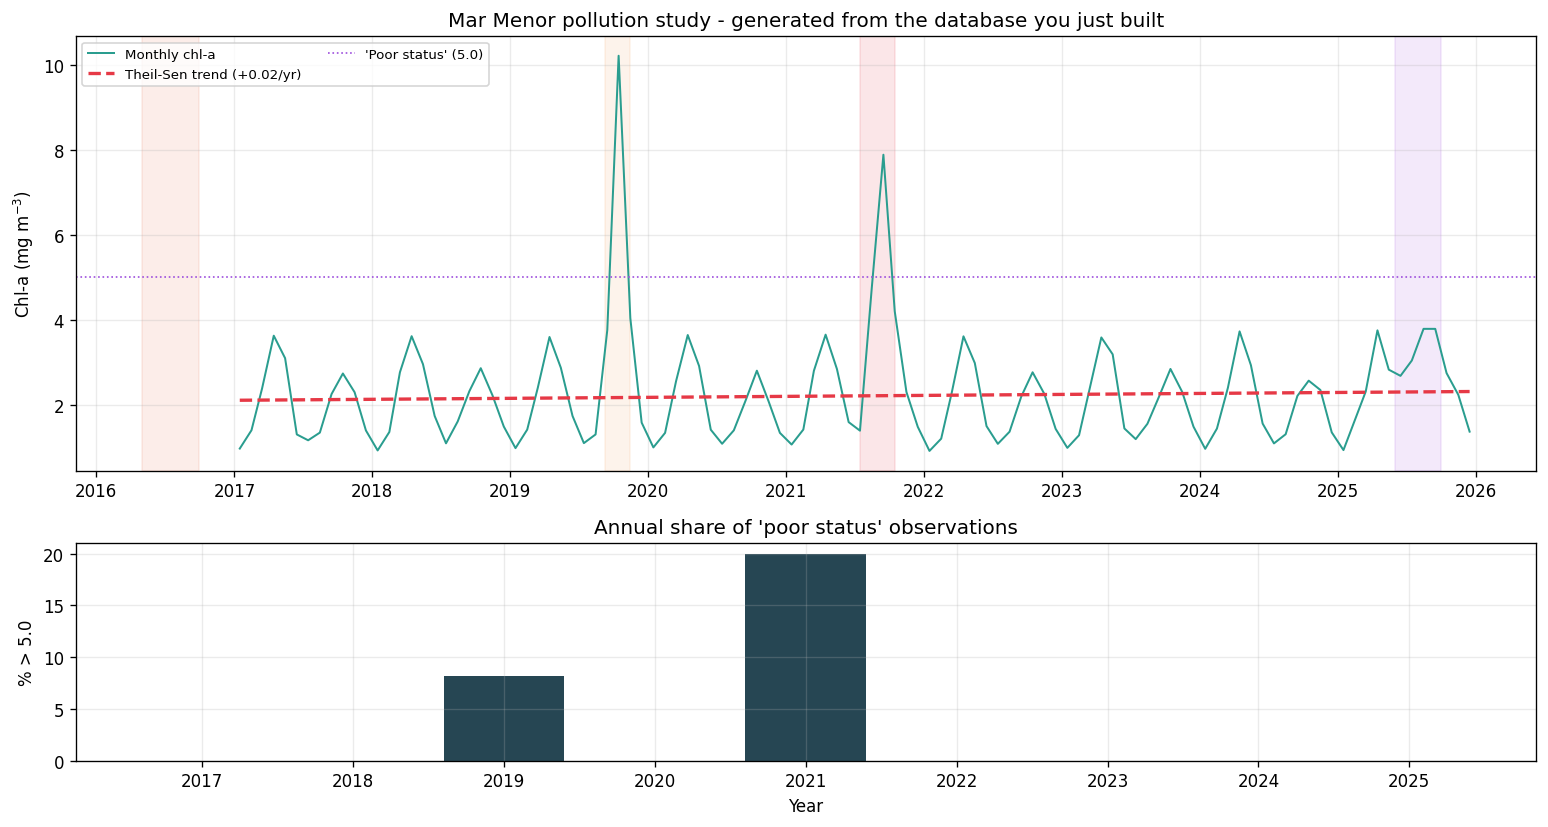

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), height_ratios=[2, 1])
ax = axes[0]
ax.plot(monthly["t"], monthly["chla"], color="#2a9d8f", lw=1.2, label="Monthly chl-a")
ax.plot(monthly["t"], intercept + slope*x, color="#e63946", lw=2, ls="--",
        label=f"Theil-Sen trend ({slope:+.2f}/yr)")
ax.axhline(THR, color="#9d4edd", lw=1, ls=":", label=f"'Poor status' ({THR})")
for s,e,c in [("2016-05-01","2016-09-30","#e76f51"),("2019-09-10","2019-11-15","#f4a261"),
              ("2021-07-15","2021-10-15","#e63946"),("2025-06-01","2025-09-30","#9d4edd")]:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=c, alpha=0.12)
ax.set_ylabel("Chl-a (mg m$^{-3}$)")
ax.set_title("Mar Menor pollution study - generated from the database you just built")
ax.legend(loc="upper left", fontsize=8, ncol=2)
axes[1].bar(exc["year"], exc["pct"], color="#264653")
axes[1].set_ylabel(f"% > {THR}"); axes[1].set_xlabel("Year")
axes[1].set_title("Annual share of 'poor status' observations")
fig.tight_layout(); plt.show()


### Joining satellite + in-situ in one query

The real power of a database is asking a question that spans sources. We load the
in-situ chl-a into a table and compare it to the satellite series with a single
`JOIN` — the match-up you would report in a validation paper.


Satellite vs in-situ monthly chl-a: Pearson r = 0.994 (n=107)


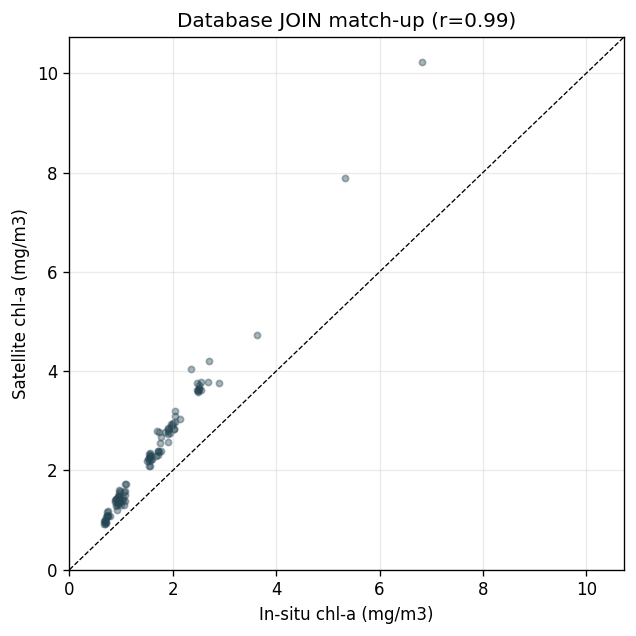

In [21]:
insitu = pd.read_parquet(DATA / "insitu_buoys_2016_2025.parquet").assign(
    date=lambda d: pd.to_datetime(d["date"]))
insitu_m = (insitu.assign(month=lambda d: d["date"].dt.strftime("%Y-%m"))
                  .groupby("month")["chla_mg_m3"].mean().reset_index())
insitu_m.to_sql("insitu_monthly", con, if_exists="replace", index=False)

compare = pd.read_sql("""
    SELECT m.month, m.chla_satellite, i.chla_mg_m3 AS chla_insitu
    FROM (SELECT substr(date,1,7) AS month, AVG(value) AS chla_satellite
          FROM observations WHERE variable='chla_mg_m3' AND zone='all'
          GROUP BY month) m
    JOIN insitu_monthly i ON m.month = i.month
    ORDER BY m.month
""", con)
r = compare["chla_satellite"].corr(compare["chla_insitu"])
print(f"Satellite vs in-situ monthly chl-a: Pearson r = {r:.3f} (n={len(compare)})")
fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.scatter(compare["chla_insitu"], compare["chla_satellite"], s=14, alpha=0.4, color="#264653")
lim = float(max(compare[["chla_insitu","chla_satellite"]].max()))*1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.8)
ax.set(xlim=(0, lim), ylim=(0, lim), xlabel="In-situ chl-a (mg/m3)",
       ylabel="Satellite chl-a (mg/m3)", title=f"Database JOIN match-up (r={r:.2f})")
fig.tight_layout(); plt.show()


---
## Part 6 — Make it grow on its own
The whole point of a database is that it **keeps growing**. Wrap Parts 1–4 in one
function and run it on a schedule; because every write is `INSERT OR REPLACE` on a
`UNIQUE` key, re-processing a date just updates it — safe to re-run forever.

```python
def update_database(con, date_from, date_to):
    scenes = search_scenes_aws(BBOX, date_from, date_to)   # 1 discover
    for sc in scenes.itertuples():                         # 2 download window
        ...                                                # 3 clean / QA
        rows = extract_observations(...)                   # 4 extract
        upsert(con, rows)                                  # idempotent store
    con.commit()

# e.g. nightly:  update_database(con, "2025-06-01", "2025-06-30")
```

**When to scale beyond a single file:**

| When you need… | Move to |
|----------------|---------|
| Spatial SQL, many users, a web map | **PostgreSQL + PostGIS** |
| Querying TBs of Parquet with no server | **DuckDB** — `duckdb.sql("SELECT AVG(ndci) FROM 'database/rasters/*.parquet'")` |
| Scheduled, monitored runs | cron / Airflow / GitHub Actions |
| A versioned data lake | partitioned Parquet (`year=/month=`) + a catalogue table |

The SQL you wrote here transfers almost unchanged to PostGIS and DuckDB — that is
why we learned the database layer instead of ad-hoc CSVs.


In [22]:
con.close()
print("Database closed and saved.")
print(f"\nYou built: {DB_PATH}")
print("Open it from any terminal:")
print("  sqlite3 database/marmenor.db")
print("  .tables")
print("  SELECT variable, COUNT(*) FROM observations GROUP BY variable;")


Database closed and saved.

You built: C:\Users\Despacho 1\Desktop\marmenor_workshop\database\marmenor.db
Open it from any terminal:
  sqlite3 database/marmenor.db
  .tables
  SELECT variable, COUNT(*) FROM observations GROUP BY variable;


---
## Exercise (~15 min)

**Q1 — your own download.** Change `DATE` in §1.1 to a cloudy winter day and a
clear summer day and compare the GIBS images. Then change `LAGOON_LAT/LON` in the
setup to *your own* study site and re-run §1.3–1.4 — you now have live pollution
and SST for anywhere on Earth.

**Q2 — extend the schema.** Add the live **air-quality** PM2.5 series to the
database: create rows with `source='openmeteo'`, `variable='pm2_5'`, store them in
`observations`, and write a query for the daily-max PM2.5.

**Q3 — pro.** Re-run the monthly mean of §5(a) with **DuckDB** straight off the
Parquet raster (`duckdb.sql("SELECT AVG(ndci) FROM 'database/rasters/*.parquet'")`)
and compare speed/ergonomics with the SQLite path.

## Wrap-up

You now own the entire chain, and you ran it live:

1. **Discover & download** from many free sources — GIBS, Sentinel-2 COGs, Open-Meteo — no login.
2. **Clean & QA** so only trustworthy pixels survive.
3. **Extract** into a tidy long-format table.
4. **Store** in a SQLite + Parquet database with idempotent, incremental writes.
5. **Analyse** with SQL: trends, exceedances, satellite↔in-situ joins.
6. **Scale** to PostGIS / DuckDB when the project grows.

Swap the `AOI`, point the downloader at your dates, and **the database builds
itself** — for the Mar Menor or for your own coast.
